In [1]:
import sys
sys.path.append('..')

from src.data_utils import cargar_metadatos_limpios

df = cargar_metadatos_limpios()
print(f"Registros válidos tras limpieza: {len(df)}")
df['split'].value_counts()

Registros válidos tras limpieza: 21374


split
train    17074
test      2156
val       2144
Name: count, dtype: int64

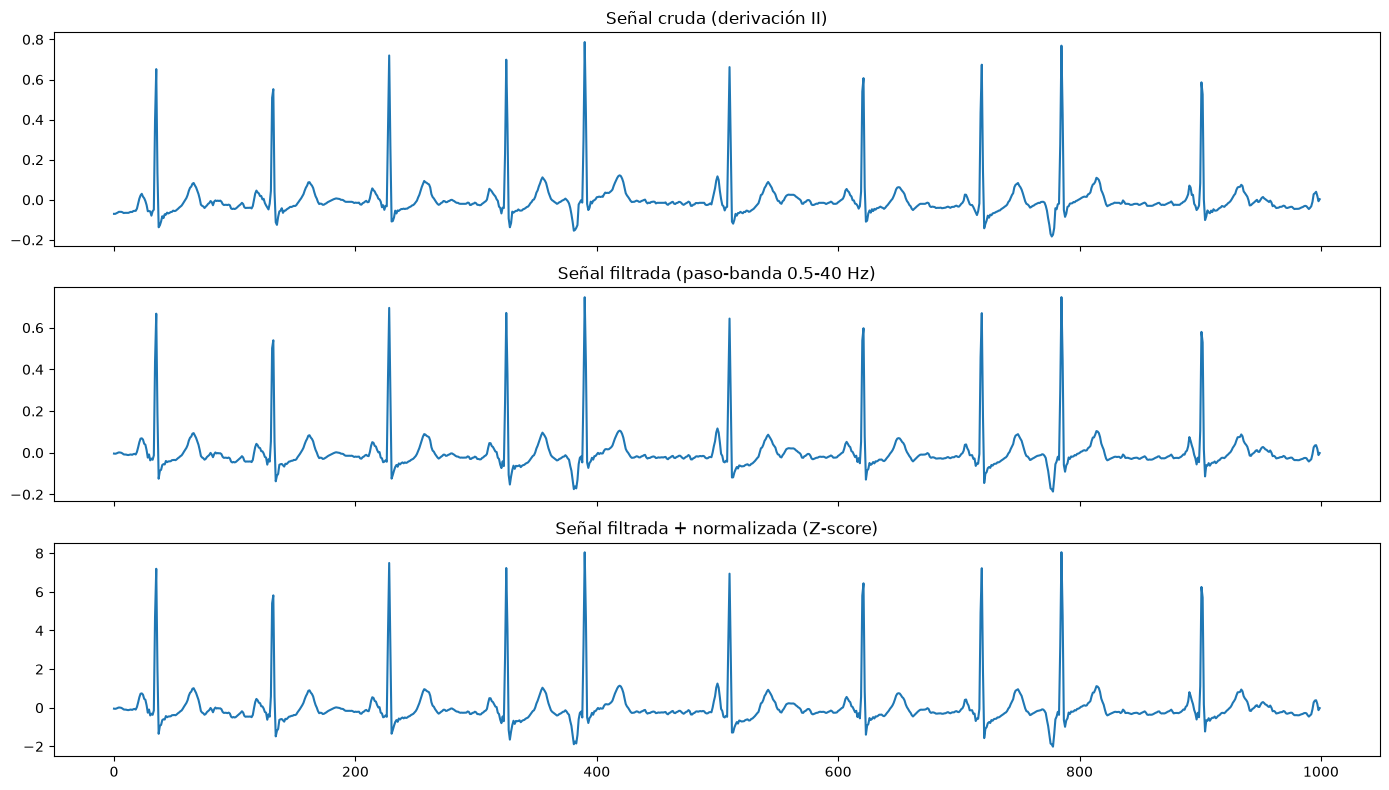

In [2]:
import matplotlib.pyplot as plt
from src.preprocessing import filtrar_señal, normalizar_z_score
import wfdb

ecg_id_ejemplo = df.index[162]
ruta_archivo = '../data/' + df.loc[ecg_id_ejemplo, 'filename_lr']

record = wfdb.rdrecord(ruta_archivo)
señal_cruda = record.p_signal

señal_filtrada = filtrar_señal(señal_cruda)
señal_final = normalizar_z_score(señal_filtrada)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(señal_cruda[:, 1])
axes[0].set_title('Señal cruda (derivación II)')
axes[1].plot(señal_filtrada[:, 1])
axes[1].set_title('Señal filtrada (paso-banda 0.5-40 Hz)')
axes[2].plot(señal_final[:, 1])
axes[2].set_title('Señal filtrada + normalizada (Z-score)')
plt.tight_layout()
plt.show()

El siguiente Apartado es para comprobar si el filtro esta haciendo algo, ya que a simple vista no puedo confirmar que el filtro funciona correctamente.

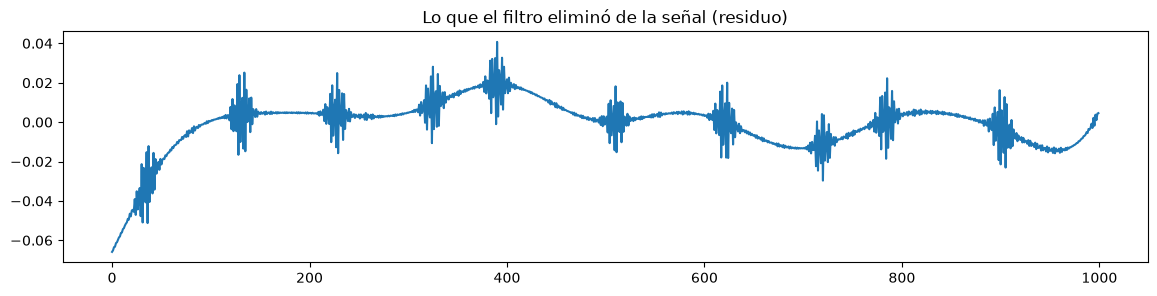

Desviación estándar de la señal cruda: 0.09364950378405643
Desviación estándar del residuo eliminado: 0.013719141594566674
Porcentaje de 'energía' eliminada: 14.649454658298275 %


In [3]:
residuo = señal_cruda[:, 1] - señal_filtrada[:, 1]

plt.figure(figsize=(14, 3))
plt.plot(residuo)
plt.title('Lo que el filtro eliminó de la señal (residuo)')
plt.show()

print("Desviación estándar de la señal cruda:", señal_cruda[:, 1].std())
print("Desviación estándar del residuo eliminado:", residuo.std())
print("Porcentaje de 'energía' eliminada:", (residuo.std() / señal_cruda[:, 1].std()) * 100, "%")

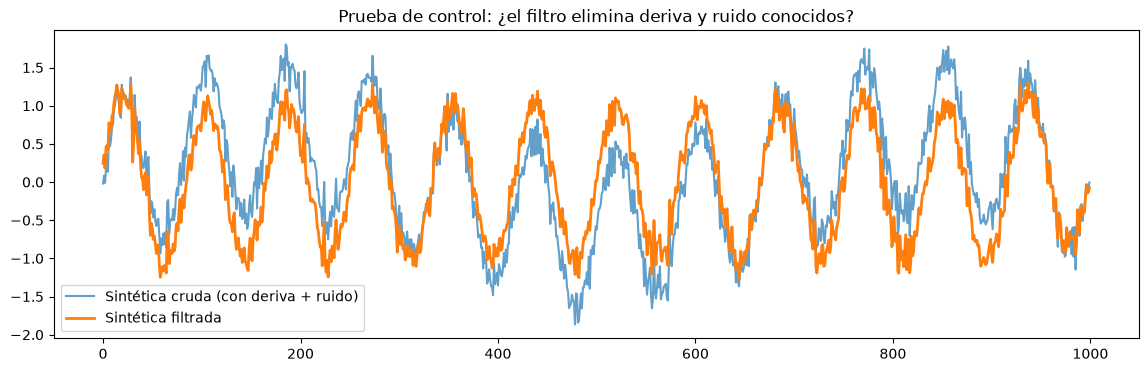

In [4]:
import numpy as np

fs = 100
t = np.linspace(0, 10, fs * 10)

latido_simulado = np.sin(2 * np.pi * 1.2 * t)          # ritmo cardíaco simulado (~72 lpm)
deriva_baja_frecuencia = 0.6 * np.sin(2 * np.pi * 0.15 * t)  # simula "baseline wander"
ruido_alta_frecuencia = 0.15 * np.random.randn(len(t))       # simula ruido eléctrico

señal_sintetica = (latido_simulado + deriva_baja_frecuencia + ruido_alta_frecuencia).reshape(-1, 1)

señal_sintetica_filtrada = filtrar_señal(señal_sintetica, fs=fs)

plt.figure(figsize=(14, 4))
plt.plot(señal_sintetica[:, 0], label='Sintética cruda (con deriva + ruido)', alpha=0.7)
plt.plot(señal_sintetica_filtrada[:, 0], label='Sintética filtrada', linewidth=2)
plt.legend()
plt.title('Prueba de control: ¿el filtro elimina deriva y ruido conocidos?')
plt.show()

In [5]:
import numpy as np
from tqdm import tqdm
from src.preprocessing import procesar_ecg

CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def construir_etiqueta(superclases):
    """Convierte la lista de superclases en un vector binario de 5 posiciones,
    ej: ['MI', 'CD'] -> [0, 1, 0, 1, 0]"""
    return [1 if clase in superclases else 0 for clase in CLASES]


def construir_split(df, split_nombre, ruta_data='../data'):
    df_split = df[df['split'] == split_nombre]

    X_lista = []
    y_lista = []
    descartados = 0

    for ecg_id, fila in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Procesando {split_nombre}"):
        ruta_archivo = f"{ruta_data}/{fila['filename_lr']}"
        señal = procesar_ecg(ruta_archivo)

        if señal is None:
            descartados += 1
            continue

        X_lista.append(señal)
        y_lista.append(construir_etiqueta(fila['superclases_diagnosticas']))

    X = np.array(X_lista, dtype=np.float32)
    y = np.array(y_lista, dtype=np.float32)

    print(f"{split_nombre}: {len(X)} registros guardados, {descartados} descartados por error de lectura")

    np.save(f'../data/processed/X_{split_nombre}.npy', X)
    np.save(f'../data/processed/y_{split_nombre}.npy', y)


for split_nombre in ['train', 'val', 'test']:
    construir_split(df, split_nombre)

Procesando train: 100%|██████████| 17074/17074 [27:37<00:00, 10.30it/s]


train: 17074 registros guardados, 0 descartados por error de lectura


Procesando val: 100%|██████████| 2144/2144 [02:27<00:00, 14.51it/s]


val: 2144 registros guardados, 0 descartados por error de lectura


Procesando test: 100%|██████████| 2156/2156 [02:23<00:00, 15.02it/s]


test: 2156 registros guardados, 0 descartados por error de lectura


In [6]:
import torch
print(torch.__version__)
print("¿GPU disponible?:", torch.cuda.is_available())

2.4.1+cpu
¿GPU disponible?: False


In [7]:
import sys
sys.path.append('..')
from torch.utils.data import DataLoader
from src.model import ECG_CNN1D
from src.dataset import ECGDataset

train_dataset = ECGDataset('../data/processed/X_train.npy', '../data/processed/y_train.npy')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

modelo = ECG_CNN1D(num_leads=12, num_classes=5)

señales, etiquetas = next(iter(train_loader))
print("Forma del batch de señales:", señales.shape)
print("Forma del batch de etiquetas:", etiquetas.shape)

salida = modelo(señales)
print("Forma de la salida del modelo:", salida.shape)

Forma del batch de señales: torch.Size([32, 12, 1000])
Forma del batch de etiquetas: torch.Size([32, 5])
Forma de la salida del modelo: torch.Size([32, 5])
